# AI5707 – Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

This notebook covers both assignment parts:
1. Generate 10,000 points per class for three Gaussian classes and compare isotropic, diagonal, and full covariance assumptions, with shared and class-specific covariance matrices.
2. Load the provided `x,y,class_label` data, perform an 80/20 stratified split, estimate Gaussian parameters by maximum likelihood, classify the test data, plot decision regions, and show confusion matrices.

Keep this notebook in the same folder as `train.txt` and `dev.txt` (or `dev(2).txt`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, roc_curve, auc, roc_auc_score
from matplotlib.colors import ListedColormap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True


## 1. Maximum-likelihood estimation

For class \(i\), the MLE estimates are
\[
\hat{\mu}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}x_k,\qquad
\hat{\Sigma}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}(x_k-\hat{\mu}_i)(x_k-\hat{\mu}_i)^T.
\]
The covariance denominator is \(n_i\), as required by maximum likelihood. The Gaussian classifier uses log-likelihood plus empirical class log-prior. A small diagonal regularizer is used for numerical stability.


In [ ]:
def fit_gaussian_classifier(X, y, covariance_type="full", shared_covariance=False, reg=1e-6):
    # Fit Gaussian class parameters using MLE.
    X, y = np.asarray(X, float), np.asarray(y)
    classes = np.unique(y)
    n, d = X.shape
    means, covs, priors = {}, {}, {}

    for cls in classes:
        Xc = X[y == cls]
        mu = Xc.mean(axis=0)
        centered = Xc - mu
        mle_cov = centered.T @ centered / len(Xc)
        if covariance_type == "isotropic":
            cov = np.eye(d) * (np.trace(mle_cov) / d)
        elif covariance_type == "diagonal":
            cov = np.diag(np.diag(mle_cov))
        elif covariance_type == "full":
            cov = mle_cov
        else:
            raise ValueError("covariance_type must be isotropic, diagonal, or full")
        means[cls], covs[cls], priors[cls] = mu, cov, len(Xc) / n

    if shared_covariance:
        pooled = np.zeros((d, d))
        for cls in classes:
            centered = X[y == cls] - means[cls]
            pooled += centered.T @ centered
        pooled /= n
        if covariance_type == "isotropic":
            pooled = np.eye(d) * np.trace(pooled) / d
        elif covariance_type == "diagonal":
            pooled = np.diag(np.diag(pooled))
        covs = {cls: pooled.copy() for cls in classes}

    return {"classes": classes, "means": means, "covariances": covs,
            "priors": priors, "reg": reg}


def log_gaussian_pdf(X, mean, cov, reg=1e-6):
    X = np.asarray(X, float)
    d = X.shape[1]
    cov = cov + reg * np.eye(d)
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-4 * np.eye(d)
        sign, logdet = np.linalg.slogdet(cov)
    diff = X - mean
    solved = np.linalg.solve(cov, diff.T).T
    quad = np.sum(diff * solved, axis=1)
    return -0.5 * (d * np.log(2*np.pi) + logdet + quad)


def predict_gaussian_classifier(model, X):
    scores = []
    for cls in model["classes"]:
        scores.append(log_gaussian_pdf(X, model["means"][cls],
                                       model["covariances"][cls], model["reg"])
                      + np.log(model["priors"][cls]))
    return model["classes"][np.argmax(np.column_stack(scores), axis=1)]


def evaluate_model(model, X_test, y_test, title):
    
    pred = predict_gaussian_classifier(model, X_test)
    labels = model["classes"]
    
    cm = confusion_matrix(y_test, pred, labels=labels)
    print(f"{title} | accuracy = {accuracy_score(y_test, pred):.4f}")
    
    display(pd.DataFrame(cm, index=[f"True {c}" for c in labels],
                         columns=[f"Pred {c}" for c in labels]))
    
    print(classification_report(y_test, pred, zero_division=0))
    
    return pred, cm


def plot_decision_boundary(model, X_test, y_test, title, max_points=2500):
    
    X_test, y_test = np.asarray(X_test), np.asarray(y_test)
    pad = 1.0
    
    xx, yy = np.meshgrid(
        np.linspace(X_test[:, 0].min()-pad, X_test[:, 0].max()+pad, 240),
        np.linspace(X_test[:, 1].min()-pad, X_test[:, 1].max()+pad, 240))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = predict_gaussian_classifier(model, grid).reshape(xx.shape)
    classes = model["classes"]
    colors = ["#d9e8ff", "#ffe0d6", "#d9f3df", "#eee0ff"]
    
    cmap = ListedColormap(colors[:len(classes)])
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=.7, cmap=cmap)
    rng = np.random.default_rng(0)
    ids = np.arange(len(X_test))
    
    if len(ids) > max_points:
        ids = rng.choice(ids, max_points, replace=False)
        
    for cls in classes:
        mask = y_test[ids] == cls
        plt.scatter(X_test[ids][mask, 0], X_test[ids][mask, 1],
                    s=10, alpha=.65, label=f"Class {cls}")
        
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 2. Synthetic data experiments

Each class contains 10,000 samples. The notebook evaluates all three covariance structures for both (i) shared covariance across classes and (ii) class-specific covariance matrices.



Shared covariance
Train: 24000 | Test: 6000
Isotropic covariance | accuracy = 0.9940


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1982,18
True 3,0,18,1982


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



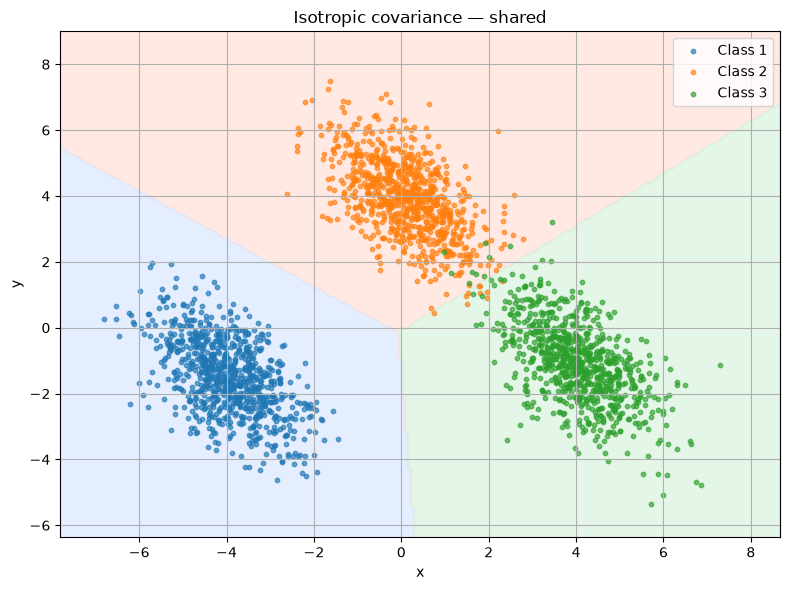

Diagonal covariance | accuracy = 0.9945


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1988,12
True 3,0,21,1979


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



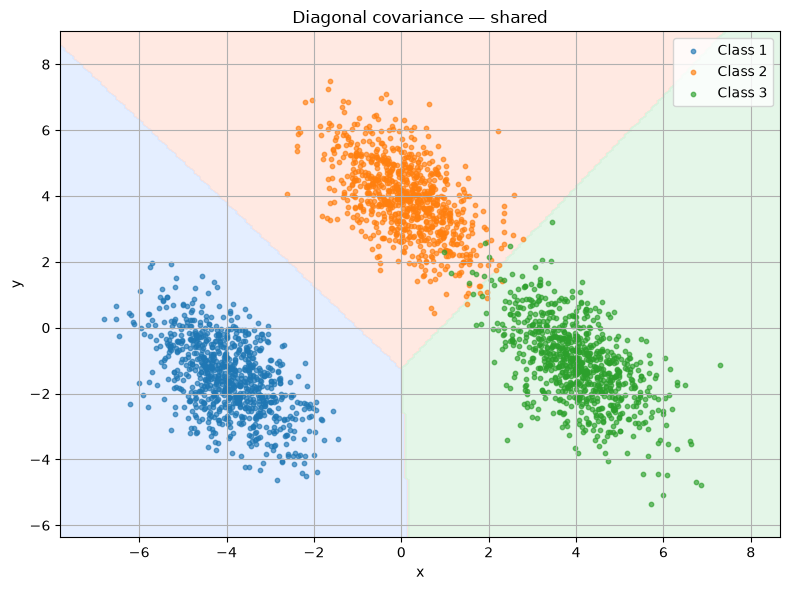

Full covariance | accuracy = 0.9943


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1987,13
True 3,0,21,1979


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



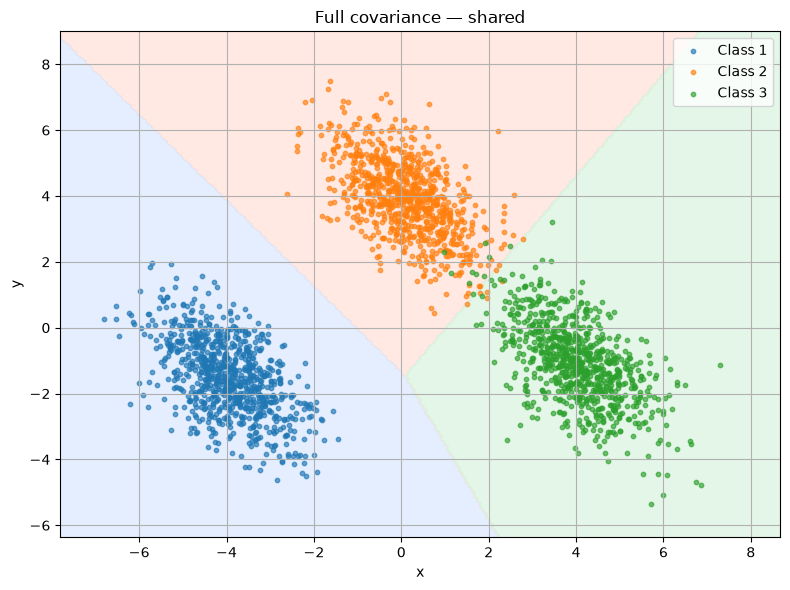


Different covariance per class
Train: 24000 | Test: 6000
Isotropic covariance | accuracy = 0.9962


,Pred 1,Pred 2,Pred 3
True 1,1999,1,0
True 2,0,1978,22
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      0.99      0.99      2000
           3       0.99      1.00      0.99      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



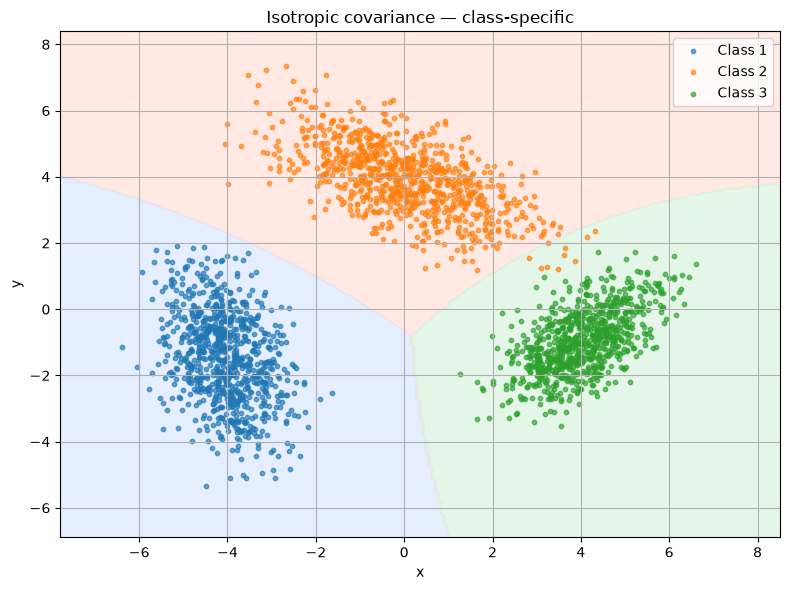

Diagonal covariance | accuracy = 0.9960


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1976,24
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      0.99      0.99      2000
           3       0.99      1.00      0.99      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



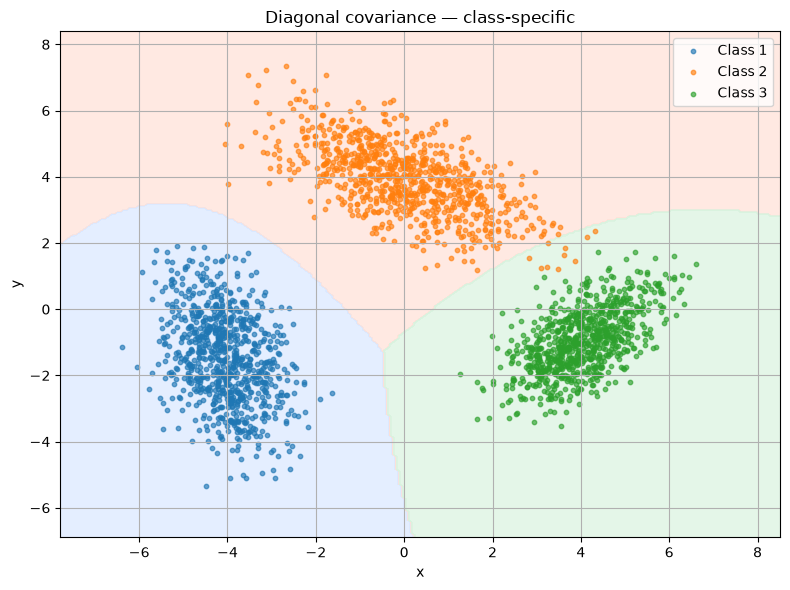

Full covariance | accuracy = 0.9993


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1998,2
True 3,0,2,1998


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



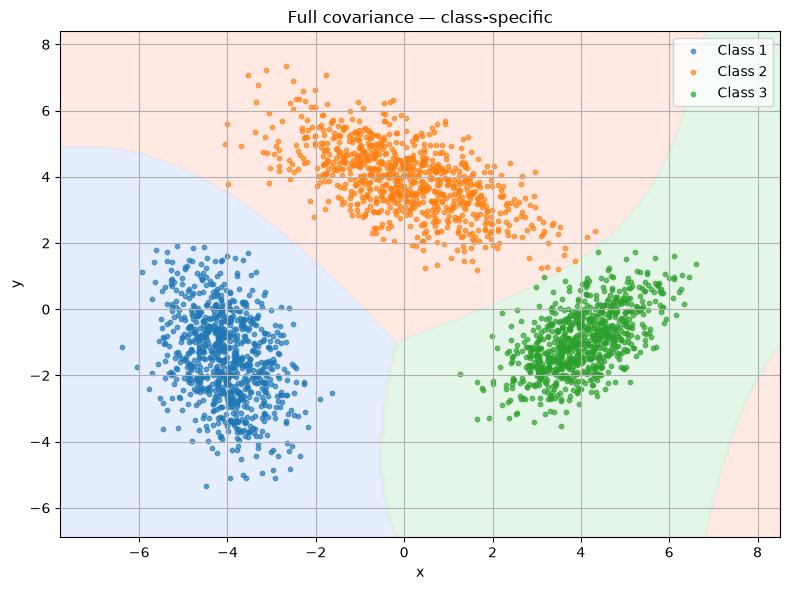

,Covariance setting,Covariance model,Test accuracy
0,Shared,isotropic,0.994000
1,Shared,diagonal,0.994500
2,Shared,full,0.994333
3,Class-specific,isotropic,0.996167
4,Class-specific,diagonal,0.996000
5,Class-specific,full,0.999333


In [3]:
means_synthetic = {
    1: np.array([-4.0, -1.5]),
    2: np.array([0.0, 4.0]),
    3: np.array([4.0, -1.0])
}

def rotated_cov(scale=1.0, angle=0.0):
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    D = np.diag([0.45*scale, 1.8*scale])
    return R @ D @ R.T

shared_cov = rotated_cov(1.0, 0.55)
class_covs = {
    1: rotated_cov(1.0, 0.2),
    2: rotated_cov(1.4, 1.0),
    3: rotated_cov(0.8, -0.7)
}

def generate_data(n_per_class=10000, shared=True, seed=42):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for cls, mu in means_synthetic.items():
        cov = shared_cov if shared else class_covs[cls]
        Xs.append(rng.multivariate_normal(mu, cov, n_per_class))
        ys.append(np.full(n_per_class, cls))
    return np.vstack(Xs), np.concatenate(ys)

synthetic_results = []
for shared in [True, False]:
    X, y = generate_data(shared=shared, seed=RANDOM_STATE + int(not shared))
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=.20, random_state=RANDOM_STATE, stratify=y)
    print("\n" + "="*75)
    print("Shared covariance" if shared else "Different covariance per class")
    print("Train:", len(Xtr), "| Test:", len(Xte))
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(Xtr, ytr, cov_type, shared_covariance=shared)
        pred, _ = evaluate_model(model, Xte, yte, f"{cov_type.title()} covariance")
        synthetic_results.append({
            "Covariance setting": "Shared" if shared else "Class-specific",
            "Covariance model": cov_type,
            "Test accuracy": accuracy_score(yte, pred)
        })
        plot_decision_boundary(model, Xte, yte,
            f"{cov_type.title()} covariance — {'shared' if shared else 'class-specific'}")
display(pd.DataFrame(synthetic_results))


## 3. Provided 2-D dataset

The files are expected to contain numeric rows in `x,y,label` format. The cell below loads the two files and combines them as the available dataset, removes exact duplicate rows, then performs a stratified 80/20 split. This directly follows the assignment's instruction to estimate on 80% and classify the remaining 20%.

If your instructor intended `train.txt` to be the training set and `dev.txt` to be the test set, use the optional fixed-split cell below instead.


In [ ]:
def locate_file(names):
    for name in names:
        p = Path(name)
        if p.exists():
            return p
    return None

train_path = locate_file(["train.txt"])
dev_path = locate_file(["dev.txt"])

def load_dataset(path):
    df = pd.read_csv(path, header=None, comment="#", skipinitialspace=True)
    if df.shape[1] < 3:
        raise ValueError(f"{path} must contain x,y,label columns")
    df = df.iloc[:, :3].copy()
    df.columns = ["x", "y", "label"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    df["label"] = df["label"].astype(int)
    return df

if train_path is None or dev_path is None:
    print("Files not found. Put train.txt and dev.txt (or dev(2).txt) beside this notebook.")
else:
    train_df = load_dataset(train_path)
    dev_df = load_dataset(dev_path)
    data_df = pd.concat([train_df, dev_df], ignore_index=True).drop_duplicates()
    print(f"Loaded {train_path} ({len(train_df)} rows) and {dev_path} ({len(dev_df)} rows)")
    print("Combined unique rows:", len(data_df))
    display(data_df["label"].value_counts().sort_index().rename("count").to_frame())
    display(data_df.head())


Loaded train.txt (1050 rows) and dev.txt (300 rows)
Combined unique rows: 1129


,count
label,
1,366
2,436
3,327


,x,y,label
0,500.00,1500.00,1
1,294.34,816.89,1
2,371.01,1207.70,1
3,390.96,2069.80,1
5,345.55,2403.10,1


Train samples: 903 (80.0%)
Test samples: 226 (20.0%)
Provided data — isotropic covariance | accuracy = 0.8097


,Pred 1,Pred 2,Pred 3
True 1,58,8,7
True 2,1,81,5
True 3,14,8,44


              precision    recall  f1-score   support

           1       0.79      0.79      0.79        73
           2       0.84      0.93      0.88        87
           3       0.79      0.67      0.72        66

    accuracy                           0.81       226
   macro avg       0.81      0.80      0.80       226
weighted avg       0.81      0.81      0.81       226



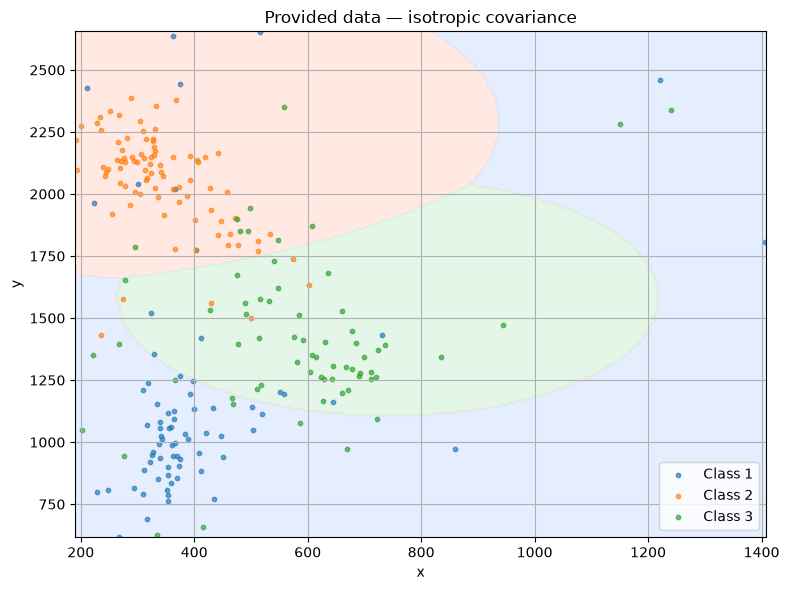

Provided data — diagonal covariance | accuracy = 0.8097


,Pred 1,Pred 2,Pred 3
True 1,58,8,7
True 2,2,78,7
True 3,12,7,47


              precision    recall  f1-score   support

           1       0.81      0.79      0.80        73
           2       0.84      0.90      0.87        87
           3       0.77      0.71      0.74        66

    accuracy                           0.81       226
   macro avg       0.80      0.80      0.80       226
weighted avg       0.81      0.81      0.81       226



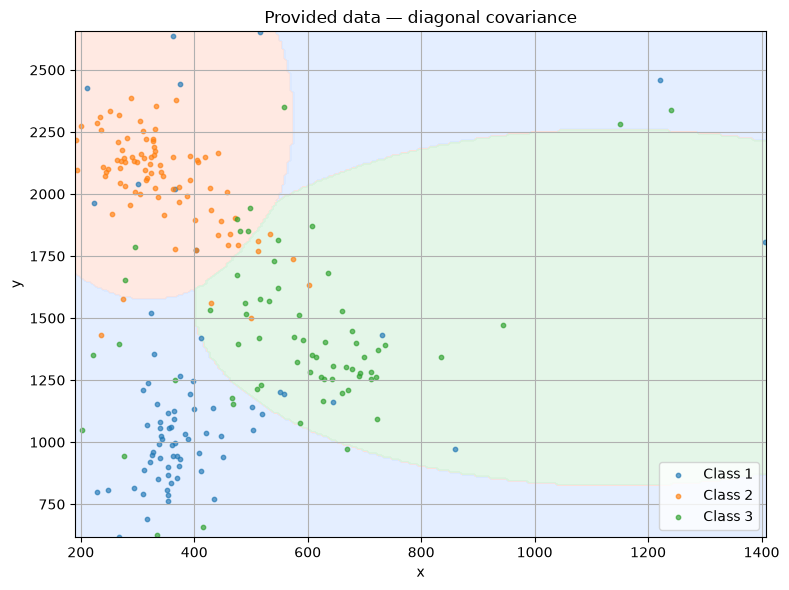

Provided data — full covariance | accuracy = 0.8230


,Pred 1,Pred 2,Pred 3
True 1,60,7,6
True 2,3,79,5
True 3,13,6,47


              precision    recall  f1-score   support

           1       0.79      0.82      0.81        73
           2       0.86      0.91      0.88        87
           3       0.81      0.71      0.76        66

    accuracy                           0.82       226
   macro avg       0.82      0.81      0.82       226
weighted avg       0.82      0.82      0.82       226



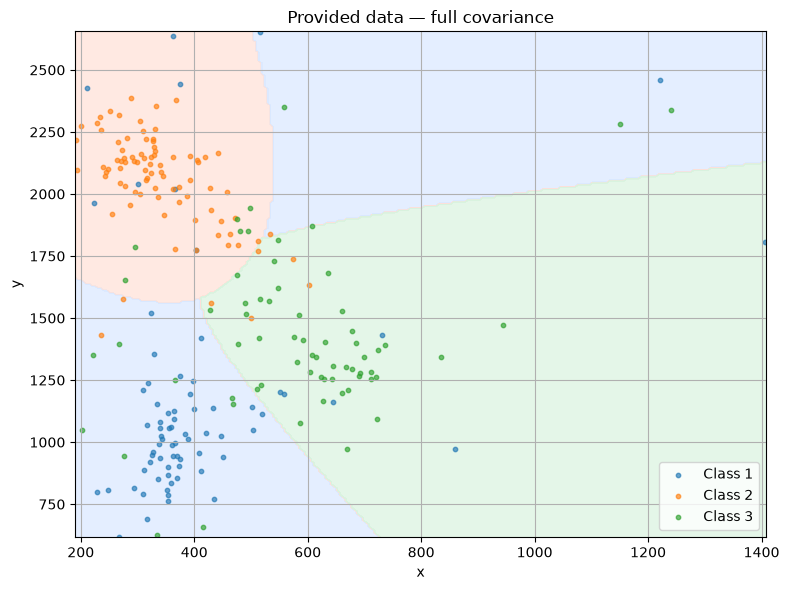

,Covariance model,Test accuracy
2,full,0.823009
0,isotropic,0.809735
1,diagonal,0.809735


In [ ]:
if train_path is not None and dev_path is not None:
    X_real = data_df[["x", "y"]].to_numpy(float)
    y_real = data_df["label"].to_numpy()
    Xtr, Xte, ytr, yte = train_test_split(
        X_real, y_real, test_size=.20, random_state=RANDOM_STATE, stratify=y_real)
    print(f"Train samples: {len(Xtr)} ({len(Xtr)/len(X_real):.1%})")
    print(f"Test samples: {len(Xte)} ({len(Xte)/len(X_real):.1%})")

    real_results = []
    
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(Xtr, ytr, cov_type, shared_covariance=False)
        pred, _ = evaluate_model(model, Xte, yte, f"Provided data — {cov_type} covariance")
        real_results.append({"Covariance model": cov_type,
                             "Test accuracy": accuracy_score(yte, pred)})
        plot_decision_boundary(model, Xte, yte, f"Provided data — {cov_type} covariance")
    display(pd.DataFrame(real_results).sort_values("Test accuracy", ascending=False))


### Optional: fixed `train.txt` / `dev.txt` split

Use this only if the two files are explicitly intended as training and held-out sets. It does not perform another random 80/20 split: the first file is used for fitting and the second for evaluation.


Fixed train/dev split — isotropic | accuracy = 0.8233


,Pred 1,Pred 2,Pred 3
True 1,74,4,22
True 2,2,87,11
True 3,9,5,86


              precision    recall  f1-score   support

           1       0.87      0.74      0.80       100
           2       0.91      0.87      0.89       100
           3       0.72      0.86      0.79       100

    accuracy                           0.82       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.82      0.82       300



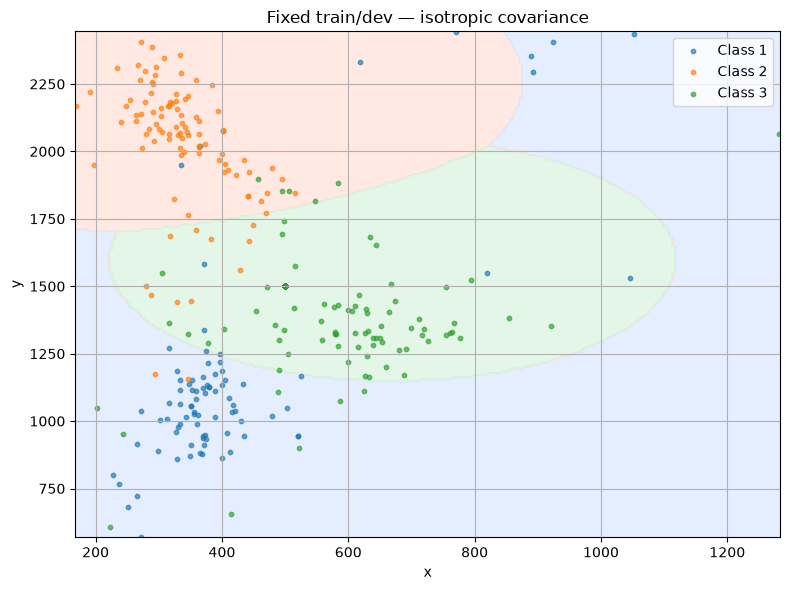

Fixed train/dev split — diagonal | accuracy = 0.8467


,Pred 1,Pred 2,Pred 3
True 1,78,2,20
True 2,6,89,5
True 3,12,1,87


              precision    recall  f1-score   support

           1       0.81      0.78      0.80       100
           2       0.97      0.89      0.93       100
           3       0.78      0.87      0.82       100

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



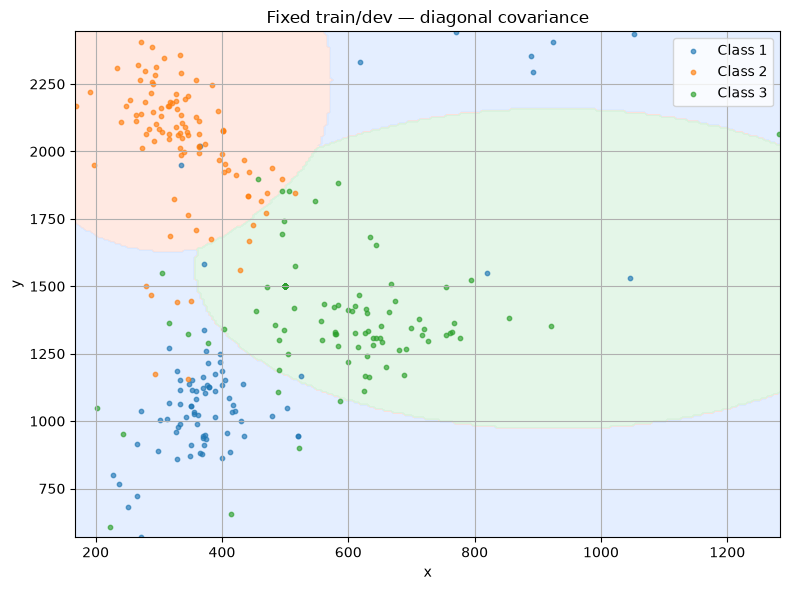

Fixed train/dev split — full | accuracy = 0.8433


,Pred 1,Pred 2,Pred 3
True 1,78,2,20
True 2,6,91,3
True 3,13,3,84


              precision    recall  f1-score   support

           1       0.80      0.78      0.79       100
           2       0.95      0.91      0.93       100
           3       0.79      0.84      0.81       100

    accuracy                           0.84       300
   macro avg       0.85      0.84      0.84       300
weighted avg       0.85      0.84      0.84       300



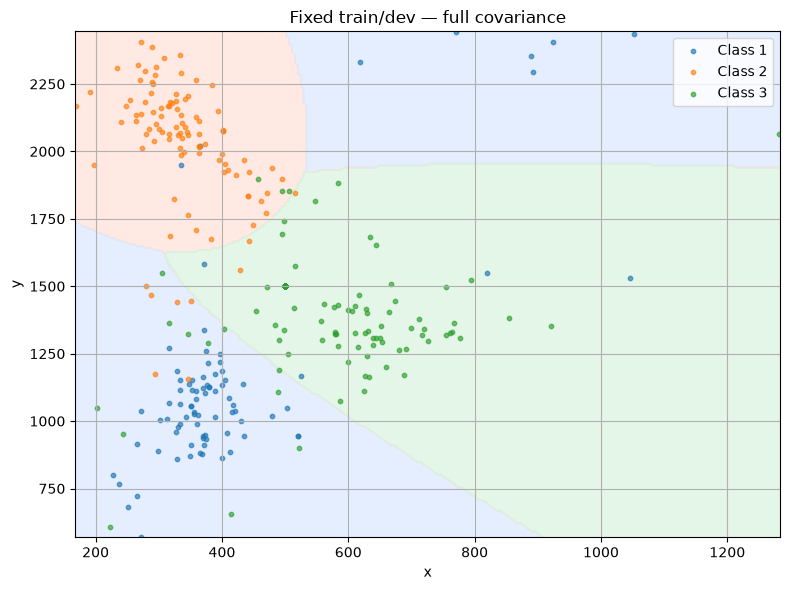

,Covariance model,Test accuracy
1,diagonal,0.846667
2,full,0.843333
0,isotropic,0.823333


In [6]:
if train_path is not None and dev_path is not None:
    Xtr_fixed = train_df[["x", "y"]].to_numpy(float)
    ytr_fixed = train_df["label"].to_numpy()
    Xte_fixed = dev_df[["x", "y"]].to_numpy(float)
    yte_fixed = dev_df["label"].to_numpy()
    fixed_results = []
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(Xtr_fixed, ytr_fixed, cov_type)
        pred, _ = evaluate_model(model, Xte_fixed, yte_fixed,
                                 f"Fixed train/dev split — {cov_type}")
        fixed_results.append({"Covariance model": cov_type,
                              "Test accuracy": accuracy_score(yte_fixed, pred)})
        plot_decision_boundary(model, Xte_fixed, yte_fixed,
                               f"Fixed train/dev — {cov_type} covariance")
    display(pd.DataFrame(fixed_results).sort_values("Test accuracy", ascending=False))


## 5. ROC curves and AUC

For multiclass classification, this section plots **one-vs-rest ROC curves** for each class and a micro-average ROC curve. AUC is computed from the classifier's continuous class scores (log posterior scores), not from hard class predictions. The diagonal line is the random-classifier reference.

The ROC plot is generated for the provided dataset's 80/20 split and for the optional fixed train/dev split when those files are available.



 Isotropic covariance — provided data


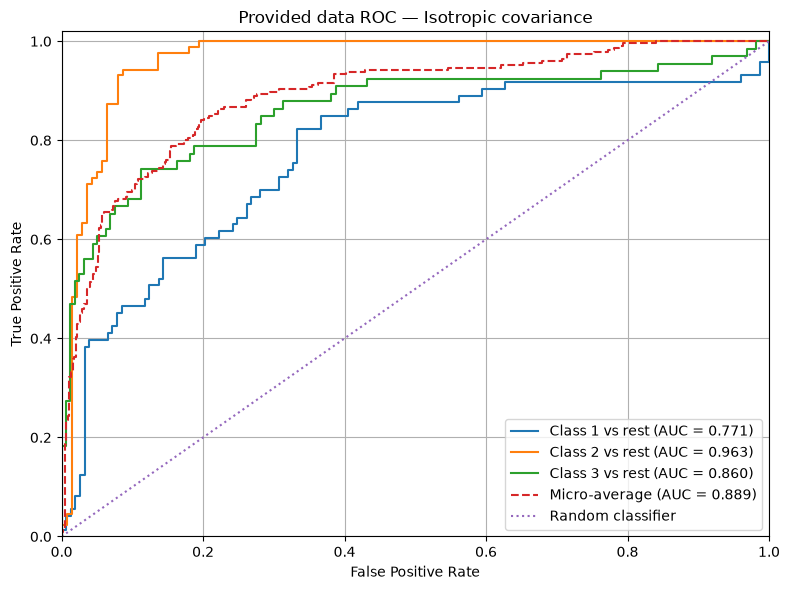

Per-class AUC: {'1': 0.7714, '2': 0.9629, '3': 0.8602}
Macro-average AUC: 0.8648
Micro-average AUC: 0.8886

 Diagonal covariance — provided data


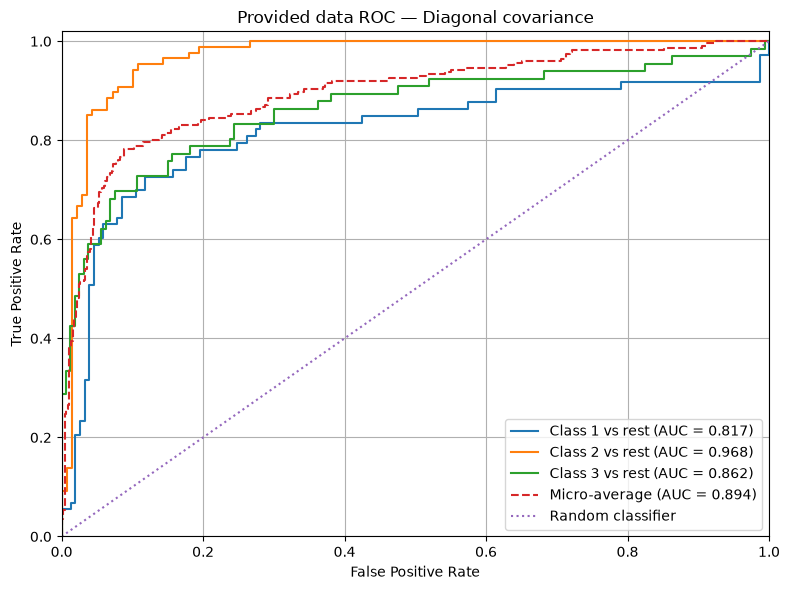

Per-class AUC: {'1': 0.8169, '2': 0.968, '3': 0.8623}
Macro-average AUC: 0.8824
Micro-average AUC: 0.8942

 Full covariance — provided data


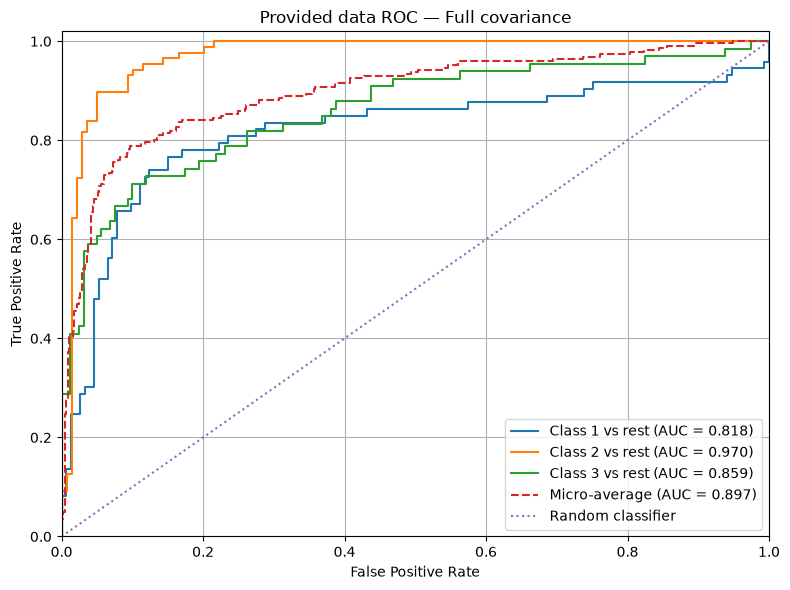

Per-class AUC: {'1': 0.8175, '2': 0.9701, '3': 0.8589}
Macro-average AUC: 0.8822
Micro-average AUC: 0.8969


,Covariance model,Macro AUC,Micro AUC
1,diagonal,0.882404,0.894187
2,full,0.882193,0.896869
0,isotropic,0.864840,0.888558


In [7]:
from sklearn.preprocessing import label_binarize

def gaussian_class_scores(model, X):
    # Continuous scores per class: log p(x | class) + log prior.
    return np.column_stack([
        log_gaussian_pdf(X, model["means"][cls], model["covariances"][cls], model["reg"])
        + np.log(model["priors"][cls])
        for cls in model["classes"]
    ])

def plot_multiclass_roc(model, X_test, y_test, title="Multiclass ROC"):
    classes = model["classes"]
    scores = gaussian_class_scores(model, X_test)
    y_bin = label_binarize(y_test, classes=classes)

    # label_binarize returns one column for a binary problem; handle both binary and multiclass.
    if len(classes) == 2:
        y_bin = np.column_stack([1 - y_bin[:, 0], y_bin[:, 0]])

    plt.figure(figsize=(8, 6))
    auc_values = {}
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        class_auc = auc(fpr, tpr)
        auc_values[str(cls)] = class_auc
        plt.plot(fpr, tpr, label=f"Class {cls} vs rest (AUC = {class_auc:.3f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
    micro_auc = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, linestyle="--",
             label=f"Micro-average (AUC = {micro_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle=":", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    macro_auc = float(np.mean(list(auc_values.values())))
    print("Per-class AUC:", {k: round(v, 4) for k, v in auc_values.items()})
    print(f"Macro-average AUC: {macro_auc:.4f}")
    print(f"Micro-average AUC: {micro_auc:.4f}")
    return {"per_class_auc": auc_values, "macro_auc": macro_auc, "micro_auc": micro_auc}


# ROC for the provided dataset's random stratified 80/20 split.
if train_path is not None and dev_path is not None:
    roc_results = []
    for cov_type in ["isotropic", "diagonal", "full"]:
        roc_model = fit_gaussian_classifier(
            Xtr, ytr, covariance_type=cov_type, shared_covariance=False
        )
        print("\n", cov_type.title(), "covariance — provided data")
        auc_result = plot_multiclass_roc(
            roc_model, Xte, yte, title=f"Provided data ROC — {cov_type.title()} covariance"
        )
        roc_results.append({
            "Covariance model": cov_type,
            "Macro AUC": auc_result["macro_auc"],
            "Micro AUC": auc_result["micro_auc"]
        })
    display(pd.DataFrame(roc_results).sort_values("Macro AUC", ascending=False))


## 6. Observations

Use the printed metrics and plots to write the final observations. Points to consider:

- Isotropic covariance assumes equal variance in all directions; diagonal covariance permits different feature variances but assumes zero correlation; full covariance estimates the correlation as well.
- A shared covariance model has class-specific means but one pooled covariance estimate. Class-specific covariance models can represent different class shapes.
- The confusion matrix's off-diagonal entries indicate which classes are being confused.
- Accuracy can change due to class overlap, covariance assumptions, sample size, and the random split.

Do not invent accuracy values: report the metrics produced when this notebook is run.
